# PS04 - Comparing Tree Methods
**Decision Trees vs. Random Forests vs. Gradient Boosting**

This assignment works through the entire modeling process, comparing the different tree models in terms of performance, bias and variance.  

We'll be using US Census data to predict, based on other attributes, whether an individual has a yearly income above or below $50 K (a binary classification).

**Process Roadmap**  

0. Load and explore the data
1. Pre-process (ordinal + one-hot encoding, imputation, train/test split)
2. Modeling x3
3. Model Assessment, Head-to-head performance comparison
4. Interpretation

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

## 0. Load & Explore

In [8]:
## fetching the data
adult, income = fetch_openml('adult', version=2, as_frame=True, return_X_y = True, parser='auto')

In [9]:
adult.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States


In [10]:
income.head()

0    <=50K
1    <=50K
2     >50K
3     >50K
4    <=50K
Name: class, dtype: category
Categories (2, object): ['<=50K', '>50K']

In [11]:
income.value_counts()

class
<=50K    37155
>50K     11687
Name: count, dtype: int64

## Inspect the data

- Do we have missing values? How should we deal with them?
- What is the split of over- and under-50K in our data?
- Are there features we have questions about?


In [12]:
adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
dtypes: category(8), int64(6)
memory usage: 2.6 MB


## 2. Pre-processing

**Imputation**
In the past, when we've had missing data, we've discarded the entire row (sample). In this example, we'll introduce *imputation*, inferring a value for missing data. And we'll start with the simplest form of imputation, replacing data with a constant value.

The transformer we use is called [`SimpleImputer`](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html) and it permits several options for filling in missing data, selectable through the `strategy` hyperparameter:

 - `mean` - the mean of available data
 - `median` - the median of available data
 - `most_frequent` - the mode of available data
 - `constant` - a user-selected value (must then set `fill_value`)

We'll use 'constant'.

**Encoding**
Some columns will require encoding and we'll apply `OrdinalEncoder` or `OneHotEncoder` when appropriate.

In [13]:
feature_names = adult.columns

si = SimpleImputer(strategy = 'constant', fill_value = 'NA')
adult = si.fit_transform(adult)

adult = pd.DataFrame(adult, columns = feature_names)
adult

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NA,103497,Some-college,10,Never-married,NA,Own-child,White,Female,0,0,30,United-States
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States


In [19]:
adult.drop(columns = 'education', inplace=True)
adult.head(2)

KeyError: "['education'] not found in axis"

In [20]:
adult.head(2)

,age,workclass,fnlwgt,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States


In [35]:
cat_features = ['workclass', 'marital-status', 
                'occupation', 'relationship', 'race', 'sex','native-country']

oh = OneHotEncoder(drop = 'if_binary')

coltrans = ColumnTransformer(
    transformers = [('robert', oh, cat_features)],
    remainder = 'passthrough',
    verbose_feature_names_out = False
)

adult_trans = coltrans.fit_transform(adult).toarray()

feature_names = coltrans.get_feature_names_out()

adult_trans = pd.DataFrame(adult_trans, columns = feature_names)

In [38]:
X_train, X_test, y_train, y_test = train_test_split(adult_trans, income, test_size = 0.2, random_state = 42)

In [39]:
X_train

,workclass_Federal-gov,workclass_Local-gov,workclass_NA,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,marital-status_Divorced,...,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
37193,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,42.0,145175.0,10.0,0.0,0.0,40.0
31093,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,52.0,175029.0,6.0,0.0,0.0,35.0
33814,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,34.0,172664.0,9.0,0.0,0.0,40.0
14500,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,28.0,125791.0,9.0,0.0,0.0,40.0
23399,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,46.0,28419.0,11.0,0.0,0.0,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,36.0,635913.0,9.0,0.0,0.0,40.0
44732,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,34.0,107624.0,10.0,0.0,0.0,50.0
38158,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,28.0,250135.0,10.0,0.0,0.0,40.0
860,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,46.0,96652.0,11.0,0.0,0.0,40.0


## 3. Modeling and Model Comparison

Let's try two comparisons, sweeping max_depth while keeping forest size at 100 and sweeping forest size while keeping max depth at 2.

- **Decision Tree** → rapidly overfits: high variance at deep depths, high bias at shallow depths.  
- **Random Forest** → averaging over many trees *reduces variance* without increasing bias much.  
- **Gradient Boosting** → each stage corrects the residual of the previous one, *reducing bias* step-by-step.

For each model, calculate and store the accuracy on the training and testing sets.

In [40]:
### Sweep max_depth
depths = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10,  15, 20])

DT_acc = {'train':[], 'test':[]}
RF_acc = {'train':[], 'test':[]}
GB_acc = {'train':[], 'test':[]}

for depth in depths:
    print(f'Depth: {depth}...')
    
    # Creating and fitting the models
    tree_clf = DecisionTreeClassifier(max_depth = depth)
    forest_clf = RandomForestClassifier(max_depth = depth, n_estimators = 100)
    boosting_clf = GradientBoostingClassifier(max_depth = depth, n_estimators = 100)

    tree_clf.fit(X_train, y_train)
    forest_clf.fit(X_train, y_train)
    boosting_clf.fit(X_train, y_train)

    # Make predictions
    y_tree_train = tree_clf.predict(X_train)
    y_tree_test = tree_clf.predict(X_test)

    y_forest_train = forest_clf.predict(X_train)
    y_forest_test = forest_clf.predict(X_test)

    y_boosting_train = boosting_clf.predict(X_train)
    y_boosting_test = boosting_clf.predict(X_test)

    # Saving the accuracy
    DT_acc['train'].append(accuracy_score(y_train, y_tree_train))
    DT_acc['test'].append(accuracy_score(y_test, y_tree_test))

    RF_acc['train'].append(accuracy_score(y_train, y_forest_train))
    RF_acc['test'].append(accuracy_score(y_test, y_forest_test))

    GB_acc['train'].append(accuracy_score(y_train, y_boosting_train))
    GB_acc['test'].append(accuracy_score(y_test, y_boosting_test))
    

Depth: 1...
Depth: 2...
Depth: 3...
Depth: 4...
Depth: 5...
Depth: 6...
Depth: 7...
Depth: 8...
Depth: 9...
Depth: 10...
Depth: 15...
Depth: 20...


In [47]:
DT_acc['test']

[0.7655850138192241,
 0.8358071450506704,
 0.8514689323369843,
 0.8514689323369843,
 0.8568942573446617,
 0.8617053946156208,
 0.8612959361244754,
 0.8617053946156208,
 0.8620124884839799,
 0.8631384993346299,
 0.8556658818712253,
 0.8399017299621251]

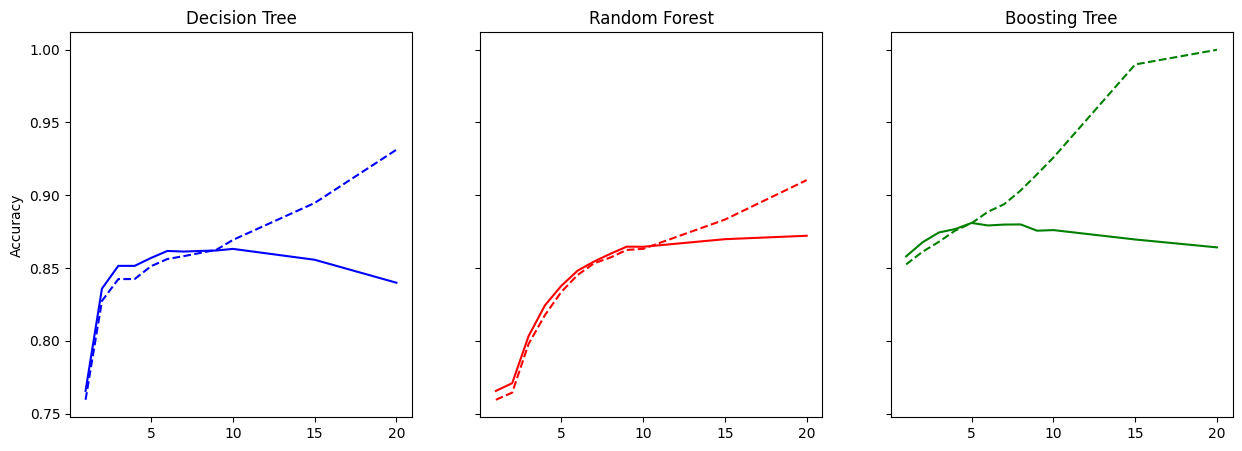

In [50]:
fig, ax = plt.subplots(1, 3, figsize = (15, 5), sharey = True)

ax[0].plot(depths, DT_acc['train'], 'b--')
ax[0].plot(depths, DT_acc['test'], 'b')

ax[1].plot(depths, RF_acc['train'], 'r--')
ax[1].plot(depths, RF_acc['test'], 'r')

ax[2].plot(depths, GB_acc['train'], 'g--')
ax[2].plot(depths, GB_acc['test'], 'g')

ax[0].set_title('Decision Tree')
ax[1].set_title('Random Forest')
ax[2].set_title('Boosting Tree')

ax[0].set_ylabel('Accuracy')
plt.show()



In [51]:
### Sweep n_estimators
n_est = np.array([2, 4, 8, 16, 32, 64, 128, 256, 512, 1028])

RF_acc = {'train':[], 'test':[]}
GB_acc = {'train':[], 'test':[]}

for n in n_est:
    print(f'Num Estimators: {n}...')
    
    # Creating and fitting the models
    forest_clf = RandomForestClassifier(max_depth = 2, n_estimators = n)
    boosting_clf = GradientBoostingClassifier(max_depth = depth, n_estimators = n)

    forest_clf.fit(X_train, y_train)
    boosting_clf.fit(X_train, y_train)

    # Make predictions
    y_forest_train = forest_clf.predict(X_train)
    y_forest_test = forest_clf.predict(X_test)

    y_boosting_train = boosting_clf.predict(X_train)
    y_boosting_test = boosting_clf.predict(X_test)

    # Saving the accuracy
    RF_acc['train'].append(accuracy_score(y_train, y_forest_train))
    RF_acc['test'].append(accuracy_score(y_test, y_forest_test))

    GB_acc['train'].append(accuracy_score(y_train, y_boosting_train))
    GB_acc['test'].append(accuracy_score(y_test, y_boosting_test))

Num Estimators: 2...
Num Estimators: 4...
Num Estimators: 8...
Num Estimators: 16...
Num Estimators: 32...
Num Estimators: 64...
Num Estimators: 128...
Num Estimators: 256...
Num Estimators: 512...
Num Estimators: 1028...


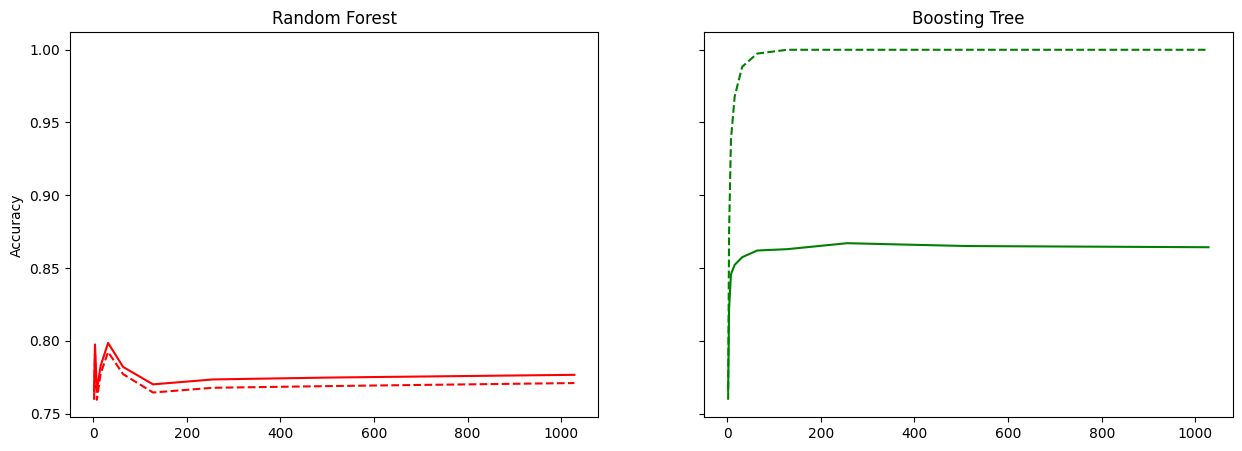

In [53]:
fig, ax = plt.subplots(1, 2, figsize = (15, 5), sharey = True)


ax[0].plot(n_est, RF_acc['train'], 'r--')
ax[0].plot(n_est, RF_acc['test'], 'r')

ax[1].plot(n_est, GB_acc['train'], 'g--')
ax[1].plot(n_est, GB_acc['test'], 'g')

ax[0].set_title('Random Forest')
ax[1].set_title('Boosting Tree')

ax[0].set_ylabel('Accuracy')
plt.show()

## 4. Visualization

Create two sets of subplots, one for each hyper-parameter sweep. Each subplot corresponds to one of the model types.

For each of these sweeps and for each model, plot a line graph showing how accuracy changes as the hyperparameter is changed, comparing trends between the training and testing set.

## Summary

| Property | Decision Tree | Random Forest | Gradient Boosting |
|---|:---:|:---:|:---:|
| **Bias** | Medium (tunable) | Medium | **Low** |
| **Variance** | **High** (overfit easily) | **Low** (averaging) | Low–Medium |
| **Interpretability** | ✅ High | ⚠️ Medium | ⚠️ Low |
| **Training speed** | ✅ Very fast | Medium | ⚠️ Slower |
| **Prediction speed** | ✅ Very fast | Medium | Medium |
| **Peak accuracy** | Lowest | Middle | **Highest** |

### Key Takeaways

1. **Decision Trees** are powerful building blocks but suffer from **high variance**. A tiny change to training data can completely alter the tree structure. 

2. **Random Forests** lessens variance by **averaging many independently-grown trees** (each trained on a random bootstrap + random feature subset). Even with deep, unconstrained trees, the ensemble generalises well. A commonly accepted belief in machine learning circles states that *you can't overfit a random forest*.

3. **Gradient Boosting** aims at reducing **bias**: each new shallow tree is fit to the *residuals* of the previous ensemble. The model starts with high bias and systematically reduces it. The cost is paid as more training time and a larger number of hyperparameters.

4. **Feature encoding** matters: the categorical columns (`education`, `occupation`, `workclass`, `relationship`, `marital-status`, `race`, `sex`, `native-country`) were one-hot encoded and contributed substantially to model performance, as confirmed by RF feature importances.

> **Practical advice:** start with a Random Forest (robust, few hyperparameters), then try Gradient Boosting (XGBoost/LightGBM in production) if you need maximum performance. Use a Decision Tree when interpretability is a hard requirement.